In [ ]:
#upload
from google.colab import files
file = files.upload()


Saving heart_disease.xlsx to heart_disease.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
wb = pd.ExcelFile('/content/heart_disease.xlsx')

In [ ]:
!pip install openpyxl

In [ ]:
for sheet_name in wb.sheet_names:
  df = pd.read_excel('/content/heart_disease.xlsx',sheet_name)
  df.to_csv(f'{sheet_name}.csv',index=False, header=True)


In [ ]:
desc = pd.read_csv('/content/Description.csv')
show_desc = desc.head(12)

In [ ]:
data = pd.read_csv('/content/Heart_disease.csv')

In [ ]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [ ]:
show_desc

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...
5,restecg,"ecg observation at resting condition, -- Val..."
6,thalch,maximum heart rate achieved
7,exang,exercise induced angina
8,oldpeak,ST depression induced by exercise relative to ...
9,slope,the slope of the peak exercise ST segment


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
data.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [ ]:
data.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [ ]:
for col in data.columns:
  print(f'{col}:  {data[col].nunique()}')

age:  49
sex:  2
cp:  4
trestbps:  85
chol:  228
fbs:  2
restecg:  3
thalch:  122
exang:  4
oldpeak:  53
slope:  3
thal:  3
num:  5


In [ ]:
sns.set_theme(style='darkgrid',palette='pastel')

Text(0.5, 1.0, 'sex vs age vs cp')

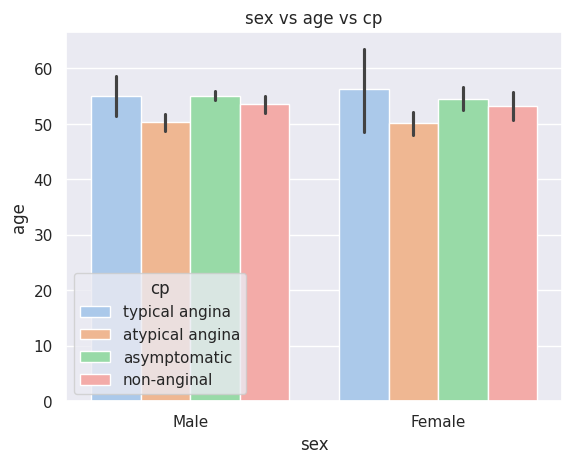

In [ ]:
sns.barplot(x='sex',y='age',data=data, hue='cp')
plt.title("sex vs age vs cp")

Based on the barplot the dataset seems balanced with both male and female having similar type of disribution of chest pain, with typical angina leading.

Text(0.5, 1.0, 'sex vs age vs fbs')

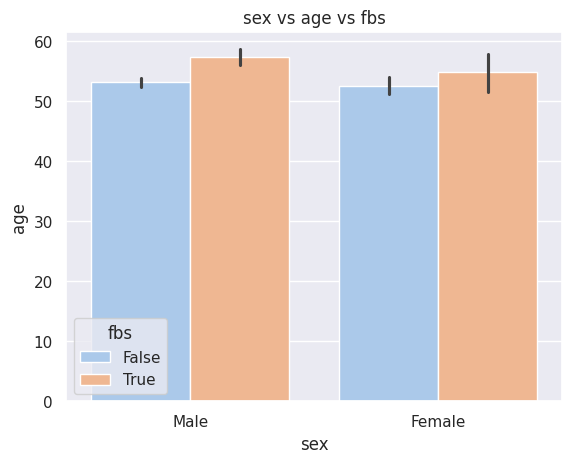

In [ ]:
sns.barplot(x='sex',y='age',data=data, hue='fbs')
plt.title("sex vs age vs fbs")

<Axes: xlabel='age', ylabel='Count'>

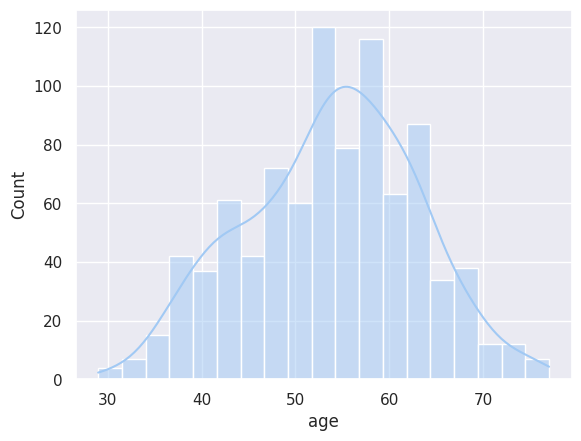

In [ ]:
sns.histplot(data['age'],kde=True)

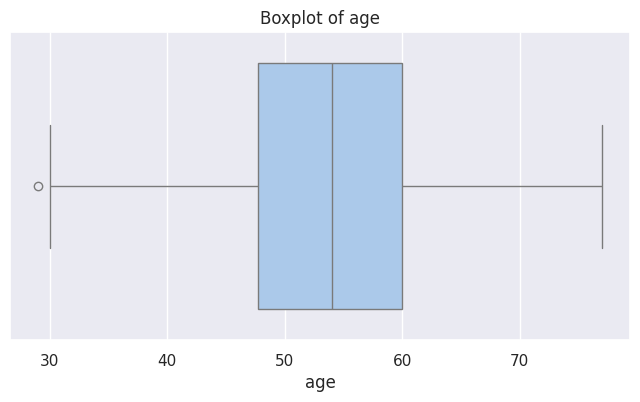

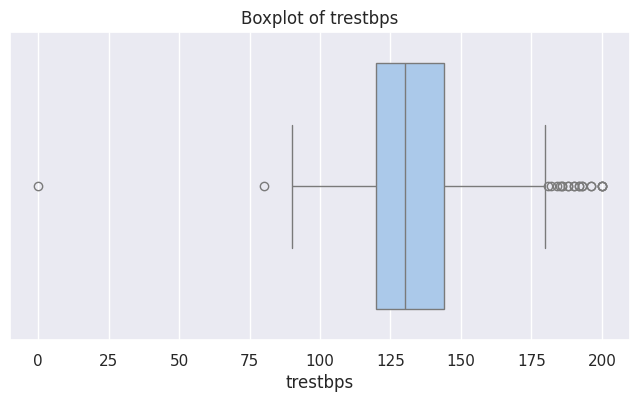

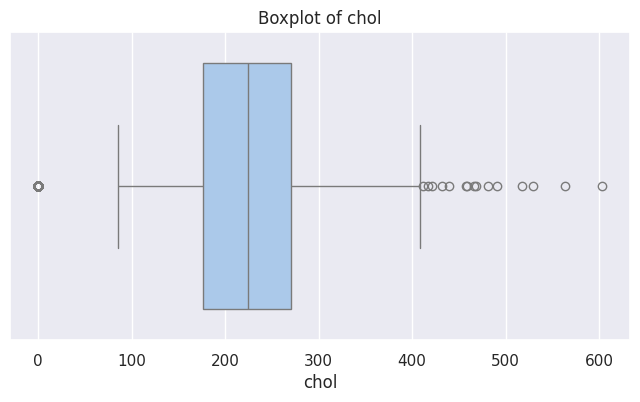

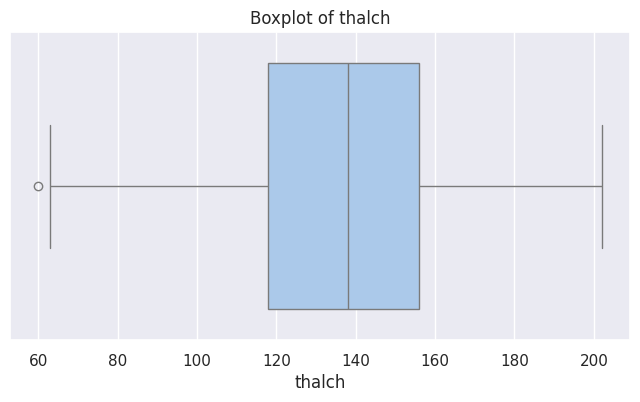

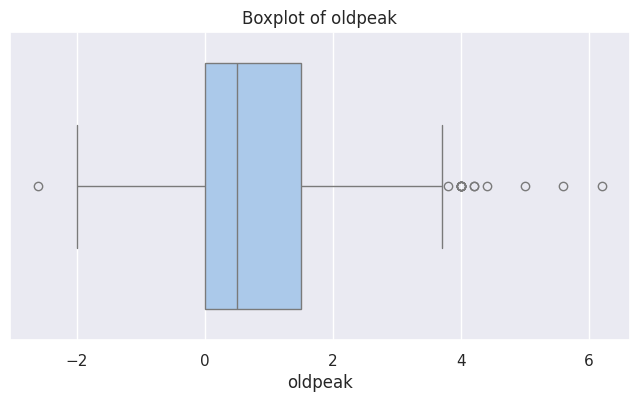

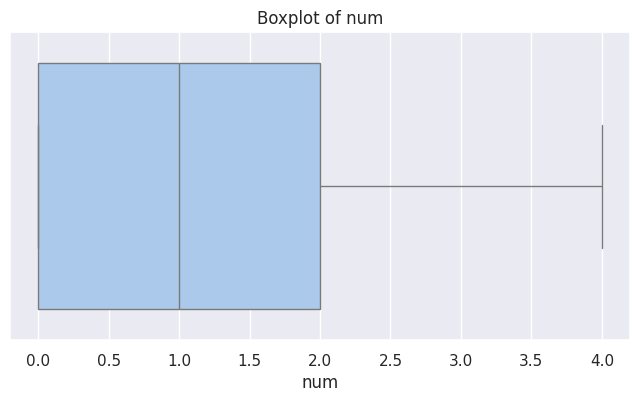

Unique values in sex: ['Male' 'Female']
Unique values in cp: ['typical angina' 'atypical angina' 'asymptomatic' 'non-anginal']
Unique values in restecg: ['lv hypertrophy' 'normal' 'st-t abnormality']
Unique values in exang: ['False' 'True' 'FALSE' 'TURE']
Unique values in slope: ['downsloping' 'flat' 'upsloping']
Unique values in thal: ['fixed defect' 'normal' 'reversable defect']


In [ ]:
# Check for outliers in numerical columns using boxplots
numerical_cols = data.select_dtypes(include=np.number).columns
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Check for unique values in categorical columns to identify potential outliers
categorical_cols = data.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f'Unique values in {col}: {data[col].unique()}')

In [ ]:
data['exang'] = data['exang'].str.lower()
data['exang'] = data['exang'].replace('ture', 'true')
print(data['exang'].unique())

['false' 'true']


In [ ]:
#label encoding the categorical variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical_cols:
  data[col] = le.fit_transform(data[col])


In [ ]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,True,0,150,0,2.3,0,0,0
1,41,1,1,135,203,False,1,132,0,0.0,1,0,0
2,57,1,0,140,192,False,1,148,0,0.4,1,0,0
3,52,1,3,118,186,False,0,190,0,0.0,1,0,0
4,57,1,0,110,201,False,1,126,1,1.5,1,0,0


In [ ]:
data['fbs'] = le.fit_transform(data['fbs'])

In [ ]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,0,2.3,0,0,0
1,41,1,1,135,203,0,1,132,0,0.0,1,0,0
2,57,1,0,140,192,0,1,148,0,0.4,1,0,0
3,52,1,3,118,186,0,0,190,0,0.0,1,0,0
4,57,1,0,110,201,0,1,126,1,1.5,1,0,0


In [ ]:
desc

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...
5,restecg,"ecg observation at resting condition, -- Val..."
6,thalch,maximum heart rate achieved
7,exang,exercise induced angina
8,oldpeak,ST depression induced by exercise relative to ...
9,slope,the slope of the peak exercise ST segment


In [ ]:
data['oldpeak'].skew()

np.float64(1.0217090718797428)

In [ ]:
#handling missing values in oldpeak using median imputation
data['oldpeak'] = data['oldpeak'].fillna(data['oldpeak'].median())

In [ ]:
#Building a decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split


In [ ]:
# Split the dataset into training and testing sets
X = data.drop('num', axis=1)
y = data['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Implement and train a Decision Tree Classification model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Evaluate the model's performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

Accuracy: 0.5110
Precision: 0.5099
Recall: 0.5110
F1-score: 0.5103


In [ ]:
parameters = { 'criterion' :('entropy','gini','log_loss'),
              'splitter': ('best' , 'random'),
              'max_depth': (1,3,5,7,9,10,11,13,15),
              'min_samples_split': (10,15,29,25,30,35,40,45,50),
              'min_samples_leaf' : (2,4,6,8,10),
              'max_features' : ('sqrt','log2',None)
}

In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
DT_Grid = GridSearchCV(estimator=dt_model, param_grid=parameters, cv=5, n_jobs=-1)

In [ ]:
DT_Grid.fit(X_train,y_train)
DT_Grid.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'max_features': None,
 'min_samples_leaf': 10,
 'min_samples_split': 30,
 'splitter': 'random'}

In [ ]:
Dt_Model = DecisionTreeClassifier(criterion='gini',
 max_depth=10,
 max_features=None,
 min_samples_leaf=10,
 min_samples_split=30,
 splitter='random')

In [ ]:
Dt_Model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=30,
                       splitter='random')

In [ ]:
y_pred = Dt_Model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

Accuracy: 0.5495
Precision: 0.4976
Recall: 0.5495
F1-score: 0.5183


In [ ]:
print(f"Train accuracy:  {Dt_Model.score(X_train,y_train)}")
print(f"Test accuracy:  {Dt_Model.score(X_test,y_test)}")



Train accuracy:  0.6060606060606061
Test accuracy:  0.5494505494505495


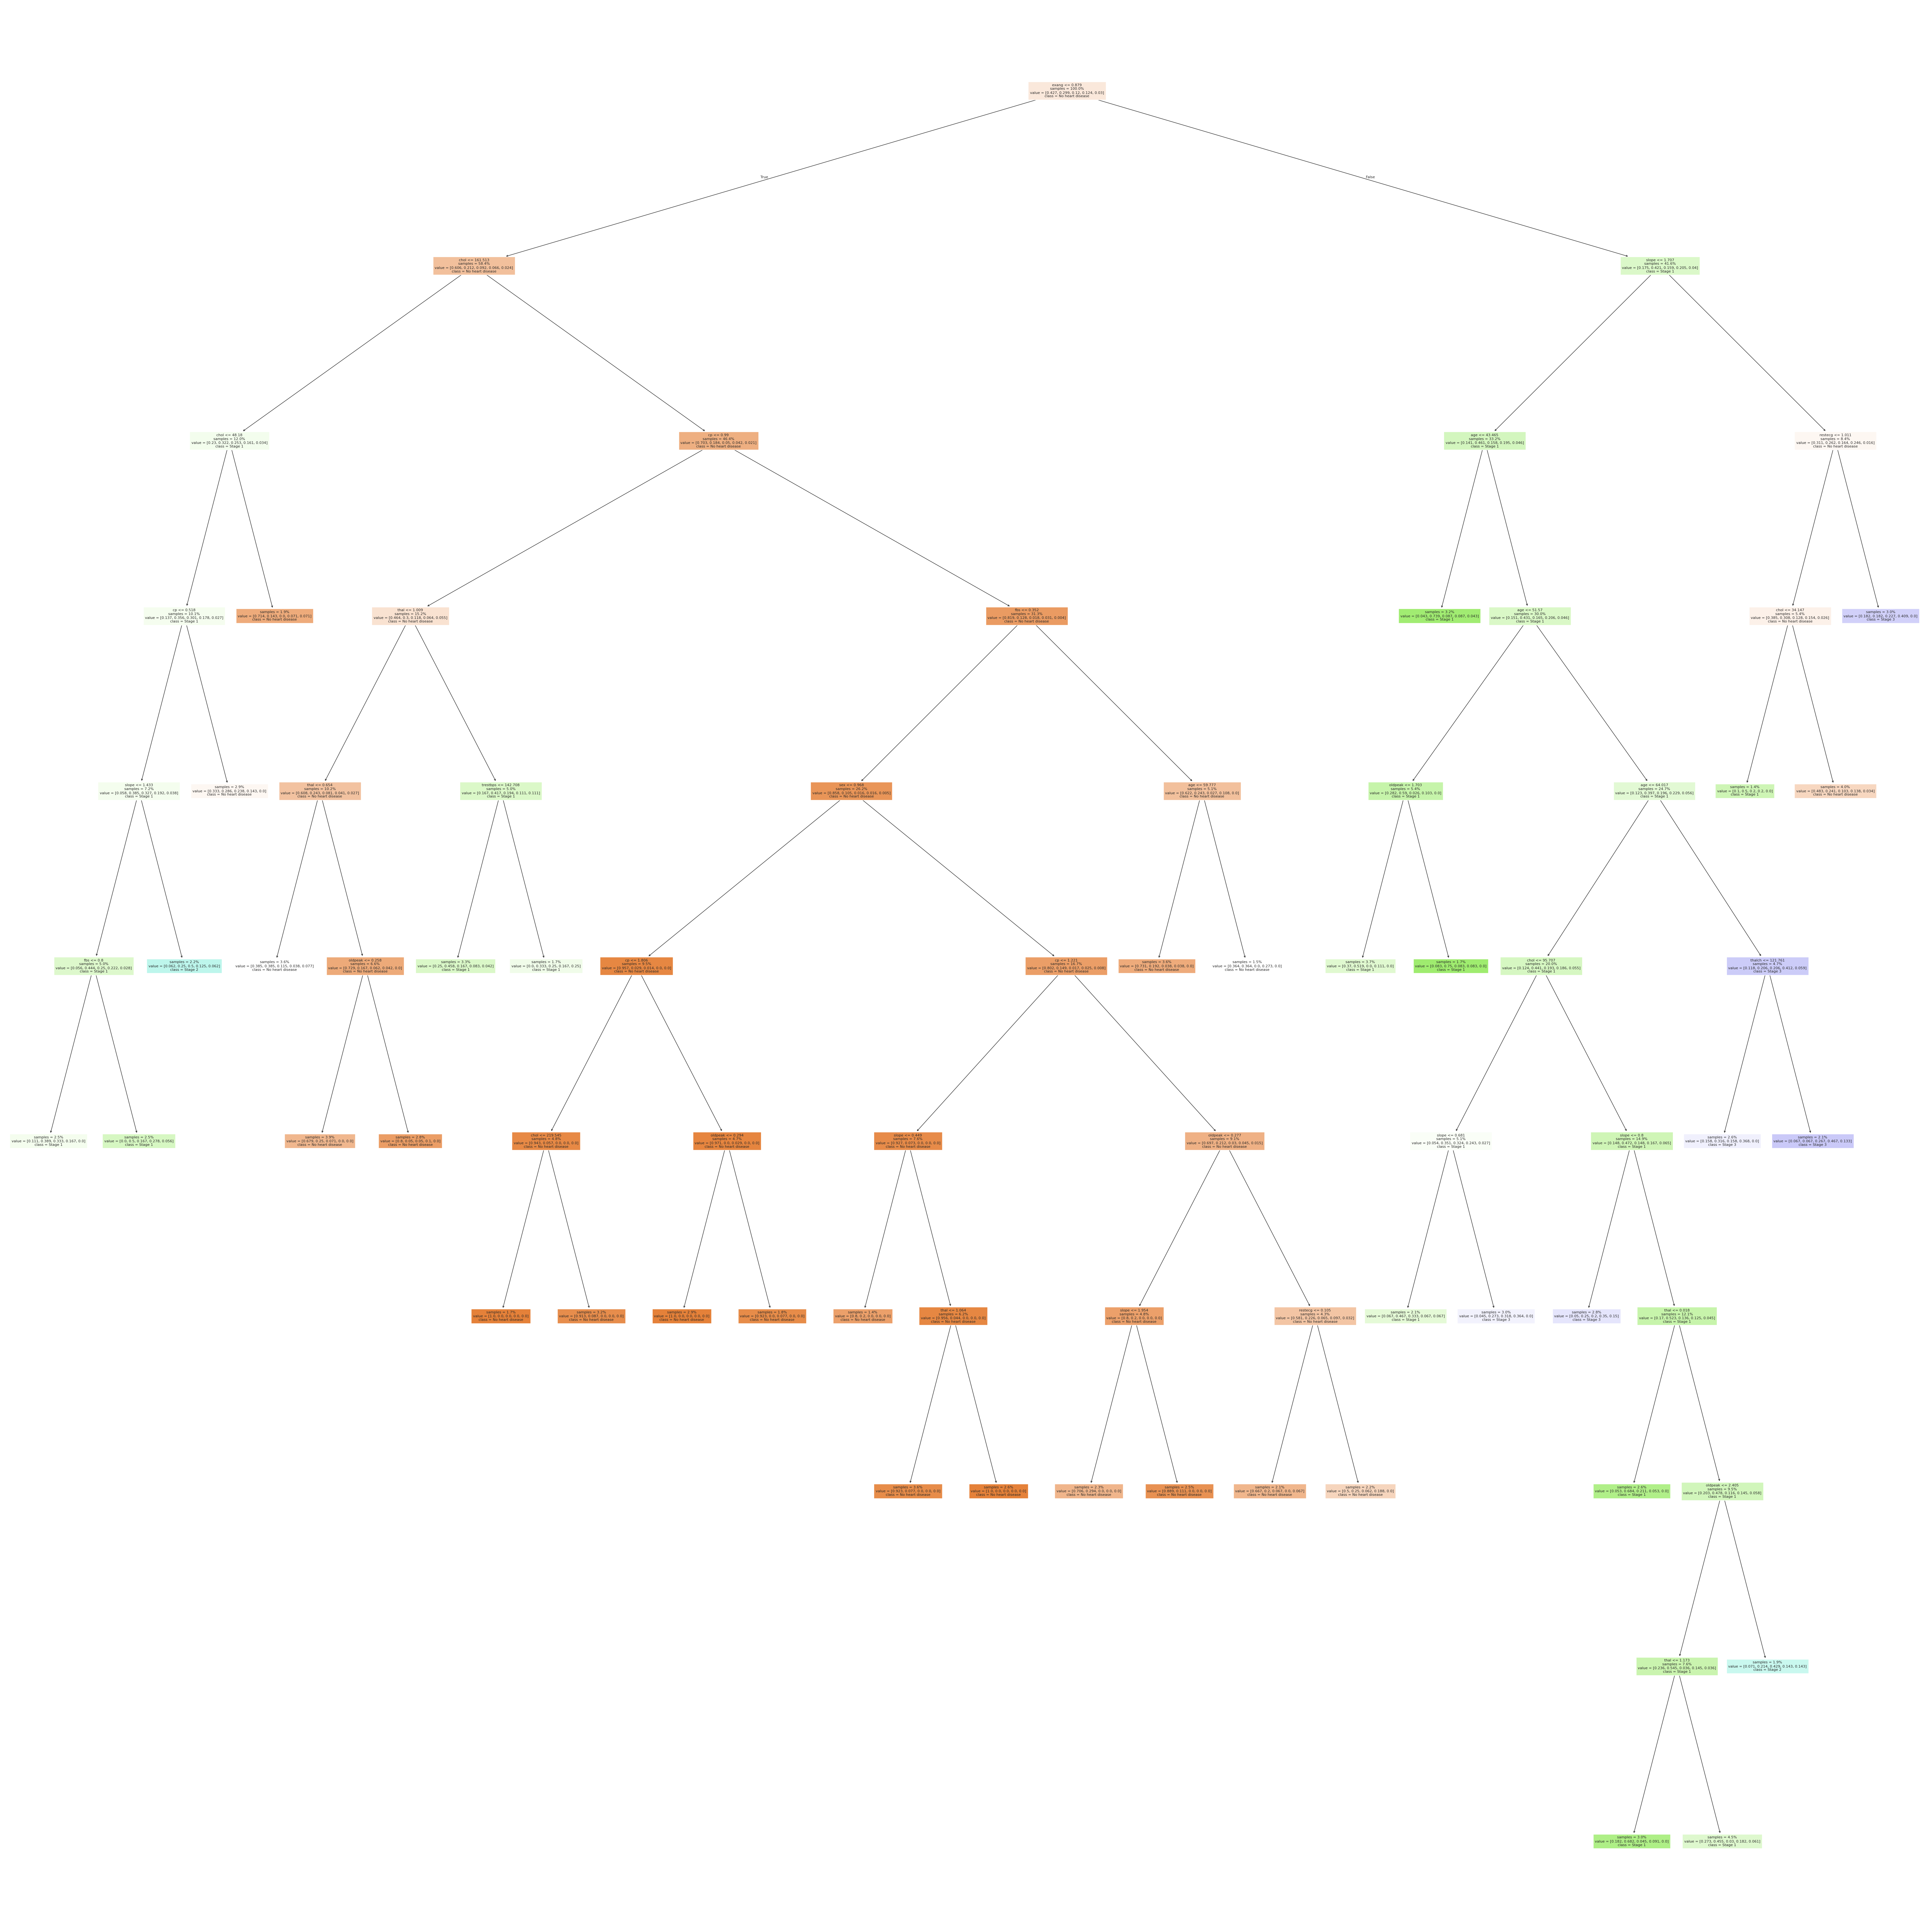

In [ ]:
#visualising decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(60, 60))  # much wider
plot_tree(
    Dt_Model,
    filled=True,
    feature_names=data.columns,
    class_names=['No heart disease','Stage 1','Stage 2','Stage 3','Stage 4'],
    fontsize=8,
    impurity=False,          # optional: remove to reduce text
    proportion=True          # optional: shorter "value" text
)
plt.tight_layout()
plt.savefig("heart_tree.svg", format="svg", dpi=300)
plt.show()


# **Interview Questions:**

# 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

**Max Depth:** This defines the maximum number of levels allowed in the tree. A deeper tree can capture more complex patterns but is highly prone to overfitting, while a shallow tree may lead to underfitting.

**Min Samples Split:** The minimum number of observations required in a node before it can be further split. Increasing this value prevents the model from learning specific, small-scale patterns that may not generalize.

**Min Samples Leaf:**  The minimum number of samples required to be at a leaf (terminal) node. This helps smooth the model, especially in regression, by ensuring each prediction is based on a sufficient amount of data.

**Max Features:** The number of features to consider when looking for the best split. Reducing this can increase the diversity of the tree and is a key component in Random Forests to reduce correlation between individual trees.

**Criterion:** The function used to measure the quality of a split. Common options include Gini Impurity (measuring how often a randomly chosen element would be incorrectly labeled) or Entropy (measuring information gain).



# 2. What is the difference between the Label encoding and One-hot encoding?

**Label Encoding**
Label encoding is a straightforward method where each unique category in a column is assigned a specific integer. For example, if you have a "Size" column with "Small," "Medium," and "Large," they might be converted to 0, 1, and 2.



Best for Ordinal Data: It is ideal for data that has a natural, inherent rank or order (e.g., Education Level, Salary Tier).


Model Compatibility: This works well with tree-based algorithms like Decision Trees or Random Forests, which can interpret the numerical order without being misled by the specific values.


The Risk: If used on data without an order (like "City" or "Brand"), many models—especially linear ones—will mistakenly assume that the category assigned "2" is somehow "greater than" or "twice as much as" the category assigned "1".


**One-Hot Encoding**
One-hot encoding creates a new binary (0 or 1) column for every unique category in the original feature. If you have three brands, it creates three new columns; if a row belongs to "Brand A," that column gets a 1, while the others get a 0.




Best for Nominal Data: It is the standard approach for categories with no internal ranking, such as the "Brand" or "BU" columns in your sales dataset.




Mathematical Compatibility: Because machine learning models perform arithmetic on inputs, they cannot "calculate" using text. One-hot encoding provides a purely numerical, binary format that models can process.



Ensuring Distance Equality: In algorithms like K-Nearest Neighbors (KNN), one-hot encoding ensures that the "distance" between any two distinct brands is always exactly the same. This prevents the model from thinking some brands are "closer" to each other than others.




The Trade-off: While it prevents false ranking, it can significantly increase the number of columns (dimensionality) if a category has hundreds of unique values, which can slow down training.
